In [10]:
import os
from collections import defaultdict
import numpy as np
import pandas as pd
import pysam
from pyBioInfo.IO.File import BedFile, BamFile
from pyBioInfo.Utils import BlockTools
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
d = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
d = d[d["UMIs"] >= 5000]
df1 = d[(d["CellLine"] == "K562") & (d["s4U"] == 0) & (d["Time"] == 3) & (d["ActD"].isna())]
df2 = d[(d["CellLine"] == "K562") & (d["s4U"] == 50) & (d["Time"] == 3) & (d["ActD"].isna())]
df2 = df2[df2["TC.Ratio"] > 0.008]
df3 = d[(d["CellLine"] == "mESC") & (d["s4U"] == 0) & (d["Time"] == 3) & (d["ActD"].isna())]
df4 = d[(d["CellLine"] == "mESC") & (d["s4U"] == 400) & (d["Time"] == 3) & (d["ActD"].isna())]
df4 = df4[df4["TC.Ratio"] > 0.008]
df_list = [df1, df2, df3, df4]

In [12]:
rows = []
for i, df in enumerate(df_list):
    vs = df["mrGenes.New"]
    print(i, len(df), np.mean(vs), np.median(vs), sep="\t")
    for v in vs:
        rows.append([i, v/1e3])
m = pd.DataFrame(rows)
m.columns = ["Type", "Genes"]

0	190	13.947368421052632	12.0
1	105	789.9619047619047	707.0
2	64	43.65625	38.0
3	110	1643.3545454545454	1592.5


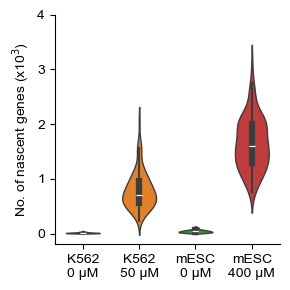

In [14]:
xs = np.arange(4)

plt.figure(figsize=(3, 3))
sns.violinplot(data=m, x="Type", y="Genes", hue="Type", 
               density_norm="width", width=0.6, linewidth=1, 
               palette=["C0", "C1", "C2", "C3"], legend=False)
plt.xlim(-0.5, 3.5)
plt.ylim(-0.2, 4)
plt.xticks(xs, ["K562\n0 μM", "K562\n50 μM", "mESC\n0 μM", "mESC\n400 μM"])
plt.xlabel(None)
plt.ylabel("No. of nascent genes (x10$^3$)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/nascent_genes.pdf")

# Make BED and BAM for gene (YTHDF2)

In [108]:
gene = "YTHDF2"
tids = ["ENST00000542507.5", "ENST00000373812.8", "ENST00000541996.5"]

gene = "GAPDH2"
tids = ["ENST00000229239.10"]

In [109]:
outdir = "results/%s" % gene
if not os.path.exists(outdir):
    os.mkdir(outdir)

In [110]:
with BedFile("/home/chenzonggui/species/homo_sapiens/GRCh38.p13/gencode.v39.annotation.transcripts.bed.gz") as f:
    transcripts = {t.name: t for t in f}
ts = [transcripts[tid] for tid in tids]
with open(outdir + "/transcripts.%s.bed" % gene, "w+") as fw:
    for t in sorted(ts):
        fw.write(t.format("BED") + "\n")

In [111]:
chrom = ts[0].chrom
start = min([t.start for t in ts])
end = max([t.end for t in ts])

In [112]:
introns_list = []
for t in ts:
    introns = tuple([(x, y) for x, y in BlockTools.gaps(t.blocks)])
    print(introns)
    introns_list.append(introns)

((6534569, 6534809), (6534861, 6536493), (6536593, 6536683), (6536790, 6536919), (6537010, 6537100), (6537216, 6537308), (6537390, 6537583), (6537996, 6538100))


In [113]:
d = pd.read_csv("../../1_FLAIRseq/reports/FLAIRseq_Summary.tsv", sep="\t")
d1 = d[(d["Group"] == "K562") & (d["s4U"] == 0) & (d["Time"] == 3) & (d["ActD"].isna())]
d2 = d[(d["Group"] == "K562") & (d["s4U"] == 50) & (d["Time"] == 3) & (d["ActD"].isna())]
print("Cells (0 uM, 3 h): %d" % len(d1))
print("Cells (50 uM, 3 h): %d" % len(d2))

Cells (0 uM, 3 h): 199
Cells (50 uM, 3 h): 189


In [126]:
for d3 in [d1, d2]:
    if d3 is d1:
        bamfile1 = outdir + "/reads.%s.0uM3h.bam" % gene
        bamfile2 = outdir + "/reads.%s.0uM3h.sorted.bam" % gene
        need_nascent = False
    else:
        bamfile1 = outdir + "/reads.%s.50uM3h.bam" % gene
        bamfile2 = outdir + "/reads.%s.50uM3h.sorted.bam" % gene
        need_nascent = True
    
    fw = None
    umi_i = 0
    max_umi = 5
    min_tc = 3
    for cell in d3["Cell"]:
        path = "../../1_FLAIRseq/results/mapping/mark_duplicate/%s/%s.bam" % (cell.split(".")[0], cell)
        path2 = "../../1_FLAIRseq/results/mismatch/ratio_consensus/%s/%s.events.tsv" % (cell.split(".")[0], cell)
        if need_nascent:
            events = pd.read_csv(path2, sep="\t")
            tc_dict = {name: tc for name, tc in events[["Name", "T-C"]].values}
        with BamFile(path, random=True) as f:
            if fw is None:
                fw = BamFile(bamfile1, "wb", f)
            alignments = defaultdict(list)
            for a in f.fetch(chrom, start, end):
                alignments[a.segment.get_tag("CN")].append(a)
            for k, v in alignments.items():
                v1 = []
                for a in v:
                    introns = tuple([(x, y) for x, y in BlockTools.gaps(a.blocks)])
                    if introns in introns_list and abs(a.start - start) < 3 and abs(a.end - end) < 3:
                        v1.append(a)
                v = v1
                
                if len(v) < 3:
                    continue
                if need_nascent and tc_dict[k] < min_tc:
                    continue
                v = v[:min(len(v), 3)]
                introns = tuple([(x, y) for x, y in BlockTools.gaps(v[0].blocks)])
                if introns in introns_list:
                    for a in v:
                        a.segment.set_tag("CN", "UMI.%d" % umi_i)
                        fw.write(a)
                    umi_i += 1
                    if umi_i >= max_umi:
                        break
        if umi_i >= max_umi:
            break
    if fw:
        fw.close()
    
    cmd1 = "samtools sort -o %s %s" % (bamfile2, bamfile1)
    cmd2 = "samtools index %s" % bamfile2
    assert os.system(cmd1) == 0
    assert os.system(cmd2) == 0

    os.remove(bamfile1)

[W::hts_idx_load3] The index file is older than the data file: ../../1_FLAIRseq/results/mapping/mark_duplicate/20220719_K562R3/20220719_K562R3.C01.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1_FLAIRseq/results/mapping/mark_duplicate/20220719_K562R4/20220719_K562R4.C01.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1_FLAIRseq/results/mapping/mark_duplicate/20220719_K562R4/20220719_K562R4.C02.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1_FLAIRseq/results/mapping/mark_duplicate/20220719_K562R4/20220719_K562R4.C03.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1_FLAIRseq/results/mapping/mark_duplicate/20220719_K562R4/20220719_K562R4.C04.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1_FLAIRseq/results/mapping/mark_duplicate/20220719_K562R4/20220719_K562R4.C05.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1

In [105]:
chrom, start, end

('chr1', 28736620, 28769775)

In [107]:
df1[df1["GeneName"] == "GAPDH"]

,GeneID,Total,Nascent,TPM,NTR,Halflife,T,DecayRate,SynthesisRate,TranscriptID,TranscriptType,GeneType,GeneName,Chrom,Start,End,Strand,Canonical,Length
3914,ENSG00000111640.15,3967.0,344.0,5386.323057,0.086715,22.924634,22.924634,0.030236,1.628604,ENST00000229239.10,protein_coding,protein_coding,GAPDH,chr12,6534516,6538371,+,True,3855
